<a href="https://colab.research.google.com/github/aminosan0000/tesuto/blob/main/comment_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import json
import time
from urllib.parse import urlparse

def fetch_all_data(base_url, video_id, duration, interval=300):
    session = requests.Session()
    all_data = []
    time_ranges = [(i, i + interval) for i in range(0, duration, interval)]

    for start_time, end_time in time_ranges:
        nonce = int(time.time() * 1000)
        url = f"{base_url}/userajax.php?c=history&m={video_id}&f={start_time}&t={end_time}&format=json&__n={nonce}&b=0&l=50"

        response = session.get(url)
        if response.status_code == 200:
            all_data.append(response.json())
        else:
            print(f"Failed to fetch data for range {start_time}-{end_time}: {response.status_code}")
            break
        time.sleep(0.5)  # To avoid hitting the server too frequently

    return all_data

def main(url):
    parsed_url = urlparse(url)
    video_id = parsed_url.path.split('/')[-1]
    base_url = f"https://{parsed_url.netloc}"

    # Assuming a maximum video duration of 8 hours (28800 seconds)
    video_duration = 28800

    all_data = fetch_all_data(base_url, video_id, video_duration)

    # Save fetched data to file
    with open("all_fetched_data.json", "w") as f:
        json.dump(all_data, f, indent=2)

    return "all_fetched_data.json"

# Example usage:　＃ここにURLを挿入
url = 'https://twitcasting.tv/jr_hirata/movie/810514435'
data_file = main(url)

# Display the result
print(f"Data has been saved to {data_file}")

# To view the data directly in the notebook:
with open(data_file, "r") as f:
    data = json.load(f)
    print(json.dumps(data, indent=2))


ストリーミング出力は最後の 5000 行に切り捨てられました。
              "id": "every_day_nemui",
              "name": "\u3044\u306c\u306e\u3071\u3093",
              "screenName": "every_day_nemui",
              "profileImage": "https://imagegw02.twitcasting.tv/image3s/pbs.twimg.com/profile_images/1847621252602871808/fVJjLMyn_normal.jpg",
              "grade": 2
            }
          },
          "timeMillis": 13804709,
          "ver": "1.0"
        },
        {
          "comment": {
            "type": "comment",
            "id": 30970728378,
            "message": "\u304a\u3084\u3059\u307f",
            "createdAt": 1738782023000,
            "author": {
              "id": "c:onichaaan123",
              "name": "\u3055 \u3048",
              "screenName": "c:onichaaan123",
              "profileImage": "https://imagegw02.twitcasting.tv/image3s/img-twitcasting.s3-us-west-1.amazonaws.com/70/e5/678aca1367355_64.jpg",
              "grade": 3
            }
          },
          "timeMillis": 13804727,


In [ ]:
import json

def extract_data(input_file, output_file):
    with open(input_file, 'r') as f:
        data = json.load(f)

    extracted_data = []

    for item in data:
        history = item.get('history', {})
        events = history.get('events', [])

        for event in events:
            comment = event.get('comment', {})
            created_at = comment.get('createdAt', None)
            message = comment.get('message', None)
            time_millis = event.get('timeMillis', None)

            if created_at and message and time_millis is not None:
                extracted_data.append({
                    'message': message,
                    'createdAt': created_at,
                    'timeMillis': time_millis
                })

    with open(output_file, 'w') as f:
        json.dump(extracted_data, f, indent=2, ensure_ascii=False)

# 使用例
input_file = 'all_fetched_data.json'  # 入力ファイル名
output_file = 'extracted_data.json'   # 出力ファイル名
extract_data(input_file, output_file)
print(f"Data has been extracted to {output_file}")


Data has been extracted to extracted_data.json


# 新しいセクション

  resampled_df = df.resample('1T').size().reset_index(name='comment_count')



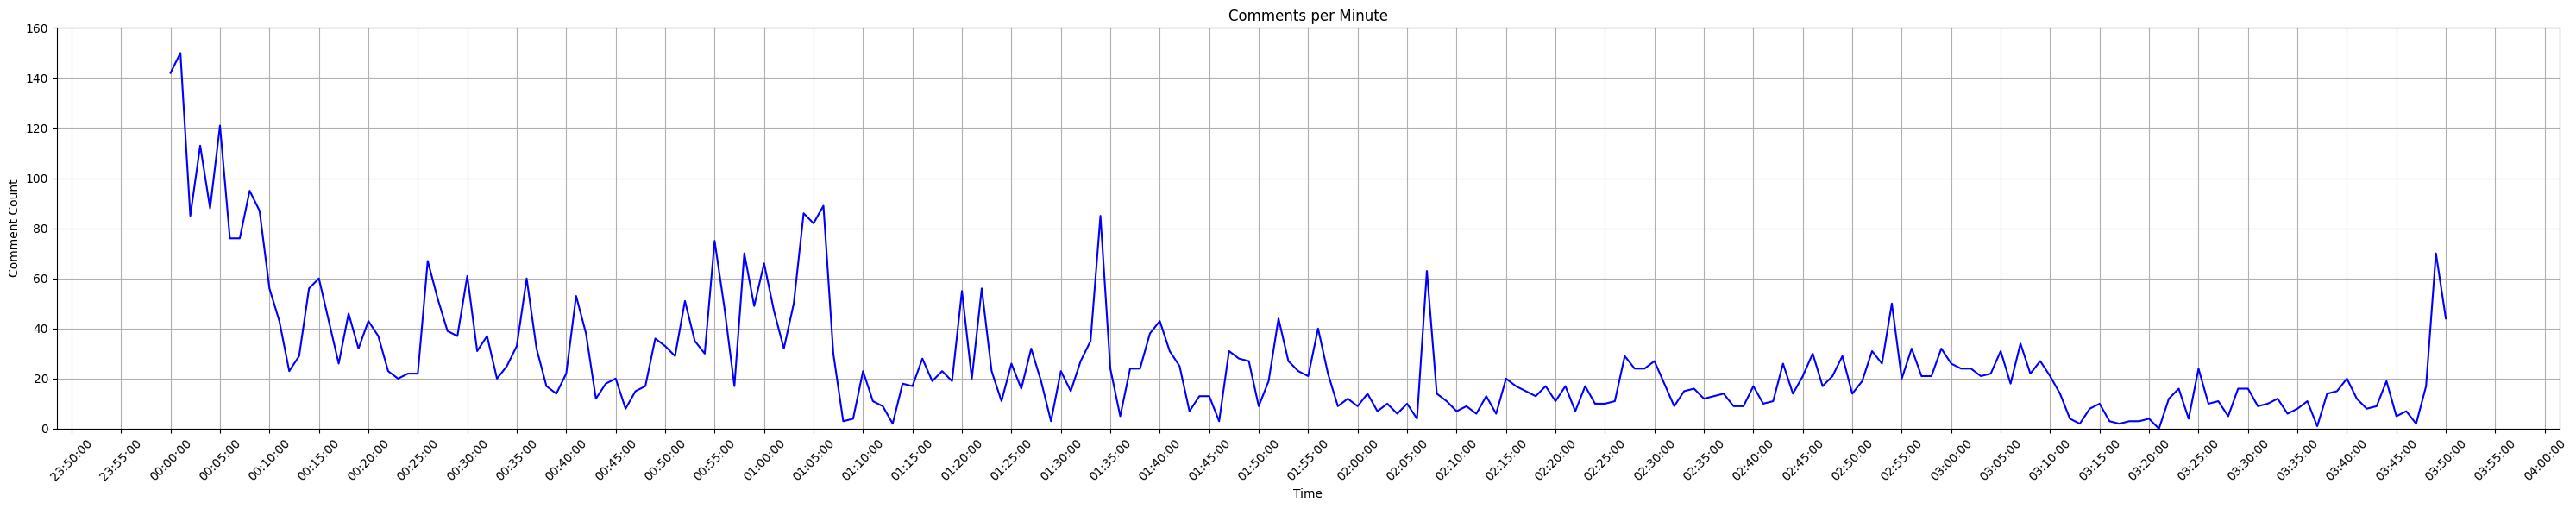

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

# JSONデータを読み込む
with open('extracted_data.json', 'r') as file:
    data = json.load(file)

# データの形式を確認し、適切な形式に整形
if isinstance(data, list):
    df = pd.DataFrame(data)
elif isinstance(data, dict) and 'data' in data:
    df = pd.DataFrame(data['data'])
else:
    raise ValueError("Unexpected JSON format")

# 'timeMillis'を経過時間からdatetimeに変換
df['timeMillis'] = pd.to_datetime(df['timeMillis'], unit='ms')

# 'timeMillis'を経過時間 (hh:mm:ss) に変換し、日付を追加してdatetime型に変換
df['elapsed_time'] = df['timeMillis'] - pd.Timestamp(0)
df['formatted_time'] = df['elapsed_time'].apply(lambda x: pd.Timestamp(0) + timedelta(milliseconds=x.total_seconds() * 1000))

# データフレームのインデックスを 'formatted_time' に設定
df.set_index('formatted_time', inplace=True)

# 1分ごとの集計
resampled_df = df.resample('1T').size().reset_index(name='comment_count')

# グラフを生成
plt.figure(figsize=(30, 6))  # 横幅を広げて比率を調整
plt.plot(resampled_df['formatted_time'], resampled_df['comment_count'], linestyle='-', color='blue')  # マーカーなし

# グラフのフォーマット設定
plt.title('Comments per Minute')
plt.xlabel('Time')
plt.ylabel('Comment Count')
plt.xticks(rotation=45, fontsize=10)  # フォントサイズを調整
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))  # ラベル間隔の調整
plt.ylim(0, resampled_df['comment_count'].max() + 10)  # 縦軸の範囲を動的に設定

# グラフの表示
plt.tight_layout()
plt.grid(True)
plt.show()


# 新しいセクション

In [ ]:
!pip install japanize_matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=87c567973e0043db07ed86a934eab627aeef176b84390dabc4372e146b817521
  Stored in directory: /root/.cache/pip/wheels/61/7a/6b/df1f79be9c59862525070e157e62b08eab8ece27c1b68fbb94
Successfully built japanize_matplotlib


  df['contains_keyword'] = df['message'].str.contains(pattern, flags=re.IGNORECASE, na=False)

  keyword_counts = df[df['contains_keyword']].resample('1T').size().reset_index(name='comment_count')



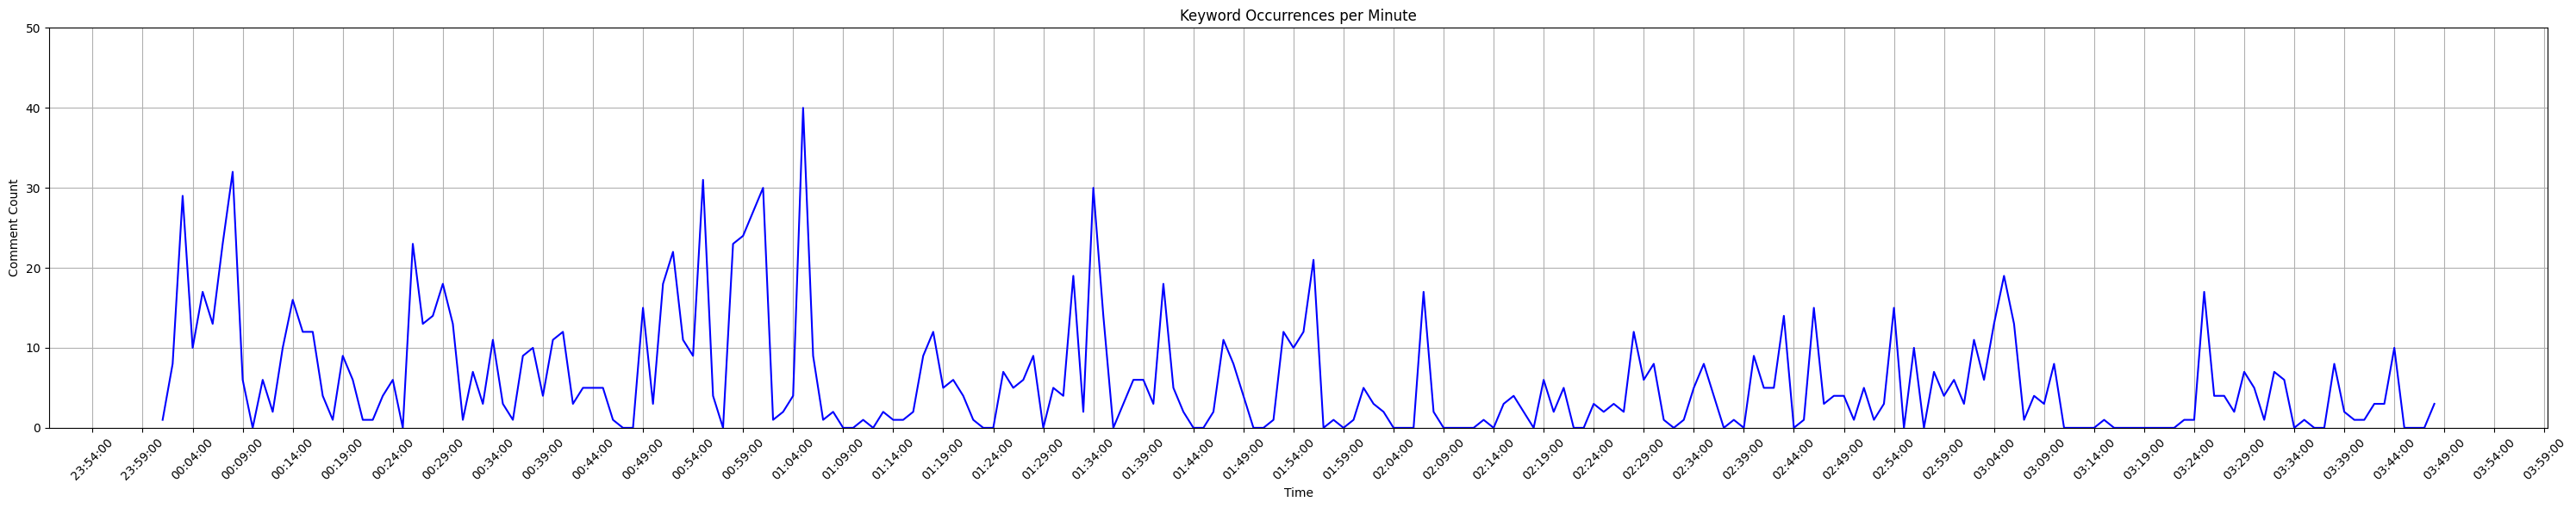

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta
import re

# JSONデータを読み込む
with open('extracted_data.json', 'r') as file:
    data = json.load(file)

# データの形式を確認し、適切な形式に変換
if isinstance(data, list):
    df = pd.DataFrame(data)
elif isinstance(data, dict) and 'data' in data:
    df = pd.DataFrame(data['data'])
else:
    raise ValueError("Unexpected JSON format")

# 'timeMillis'を経過時間からdatetimeに変換
df['timeMillis'] = pd.to_datetime(df['timeMillis'], unit='ms')

# 'timeMillis'を経過時間（hh:mm:ss）に変換し、日付を追加してdatetime型に変換
df['elapsed_time'] = df['timeMillis'] - pd.Timestamp(0)
df['formatted_time'] = df['elapsed_time'].apply(lambda x: pd.Timestamp(0) + timedelta(milliseconds=x.total_seconds() * 1000))

# データフレームのインデックスを"formatted_time"に設定
df.set_index('formatted_time', inplace=True)

# 特定のワードを含むメッセージを抽出する正規表現パターン
pattern = r'((w{2,}|笑{2,}|\(笑\){2,}|わら|草{2,}|くさ|w|笑|\(笑\)))'

# ワードごとにフィルタリングし、出現回数を集計
df['contains_keyword'] = df['message'].str.contains(pattern, flags=re.IGNORECASE, na=False)

# 各キーワードの出現数を1分ごとに集計
keyword_counts = df[df['contains_keyword']].resample('1T').size().reset_index(name='comment_count')

# グラフを生成
plt.figure(figsize=(30, 6))  # 横幅を広げて比率を調整
plt.plot(keyword_counts['formatted_time'], keyword_counts['comment_count'], linestyle='-', color='b')

# グラフのフォーマット設定
plt.title('Keyword Occurrences per Minute')
plt.xlabel('Time')
plt.ylabel('Comment Count')
plt.xticks(rotation=45, fontsize=10)  # フォントサイズを調整
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))  # 5分ごとに目盛りを設定
plt.ylim(0, keyword_counts['comment_count'].max() + 10)  # 縦軸の範囲を動的に設定

# グラフの表示
plt.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
!cp /content/comments.mp4 /content/drive/MyDrive/

In [ ]:
import json
import cv2
import numpy as np
from moviepy.editor import VideoClip
from PIL import ImageFont, ImageDraw, Image
from IPython.display import display, HTML
import os
from google.colab import files

# 設定
WIDTH, HEIGHT = 640, 360  # 動画サイズ
FPS = 30  # フレームレート
LINE_HEIGHT = 30  # コメント1行分の高さ（重ならないようにする）

# **ここを変更（抽出したい時間帯を設定）**
start_time = 3420   # 例: 1時間（3600秒）
end_time = 3720     # 例: 1時間1分（3660秒）

# **フォントのインストール（MS Pゴシックの代用）**
!apt-get update && apt-get install -y fonts-mplus
FONT_PATH = "/usr/share/fonts/truetype/mplus/mplus-1m-bold.ttf"  # 太字のM+フォント

# **フォントの読み込み**
def get_font():
    return ImageFont.truetype(FONT_PATH, 25, encoding="unic")  # サイズ30で読み込む（太くする）

font = get_font()

# **コメント速度の計算関数**
def calculate_speed(text_length, char_width=20, duration=60, min_speed=5):
    """
    文字数に応じたスクロール速度を計算
    text_length: 文字数
    char_width: 1文字あたりの幅（ピクセル）
    duration: 画面を横切る時間（秒）
    min_speed: 最低速度
    """
    distance = text_length * char_width  # 必要な移動距離
    speed = distance / duration  # 速度 = 距離 / 時間
    return max(speed, min_speed)  # 最低速度を保証

# JSONデータを読み込む
json_file = "extracted_data.json"
if not os.path.exists(json_file):
    print(f"ファイル {json_file} が見つかりません。")
else:
    with open(json_file, "r", encoding="utf-8") as file:
        data = json.load(file)

# **指定時間内のコメントを抽出**
comments = []
y_positions = []  # コメントの `y` 座標を管理するリスト
for item in data:
    comment_time = item["timeMillis"] / 1000  # ミリ秒 → 秒変換
    if start_time <= comment_time <= end_time:
        text = item["message"]
        text_length = len(text)  # 文字数取得
        speed = calculate_speed(text_length)  # 文字数から速度を計算

        # **できるだけ既存のコメントと被らないYを探す**
        available_y = None
        for y in range(0, HEIGHT - LINE_HEIGHT, LINE_HEIGHT):
            if not any(abs(y - other_y) < LINE_HEIGHT for other_y in y_positions):
                available_y = y
                break
        if available_y is None:  # もし `y` が足りなければ、適当に配置
            available_y = (len(y_positions) * LINE_HEIGHT) % HEIGHT
        y_positions.append(available_y)  # 使用した `y` を記録

        comments.append({
            "text": text,
            "start": comment_time - start_time,  # **動画の0秒地点を基準に変換**
            "speed": speed,  # **文字数に応じた速度を設定**
            "color": (255, 255, 255),
            "y": available_y  # **コメントの `y` 座標を記録**
        })

# **動画の長さを指定範囲にする**
DURATION = end_time - start_time

# 1フレームごとに画像を作成する関数
def make_frame(t):
    img = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    img_pil = Image.fromarray(img)
    draw = ImageDraw.Draw(img_pil)

    for comment in comments:
        elapsed = t - comment["start"]
        if elapsed >= 0:
            speed = comment["speed"]
            x_pos = WIDTH - int(elapsed * speed * FPS)

            # **文字の横幅を計算**
            text_width = len(comment["text"]) * 20  # 1文字20px想定

            # **完全に画面外に出るまで表示**
            if x_pos > -text_width:
                try:
                    # **シャドウ（黒）**
                    shadow_offset = 2
                    draw.text((x_pos + shadow_offset, comment["y"] + shadow_offset),
                              comment["text"], font=font, fill=(0, 0, 0))  # 黒い影
                    # **本体（白）**
                    draw.text((x_pos, comment["y"]), comment["text"], font=font, fill=comment["color"])
                except Exception as e:
                    print(f"draw.text() でエラー発生: {e}")

    return np.array(img_pil)

# 動画を作成
output_path = "output.mp4"
video = VideoClip(make_frame, duration=DURATION)
video.write_videofile(output_path, fps=FPS, codec="libx264")

# Colab 上で動画をプレビュー
from base64 import b64encode

def show_video(video_path):
    mp4 = open(video_path, "rb").read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    display(HTML(f"""
        <video width="640" height="360" controls>
            <source src="{data_url}" type="video/mp4">
        </video>
    """))

show_video(output_path)

# ファイルをダウンロード
files.download(output_path)

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

Moviepy - Done !
Moviepy - video ready output.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


import json
import cv2
import numpy as np
from moviepy.editor import VideoClip
from PIL import ImageFont, ImageDraw, Image
from IPython.display import display, HTML
import os
from google.colab import files

# 設定
WIDTH, HEIGHT = 640, 360  # 動画サイズ
FPS = 30  # フレームレート
LINE_HEIGHT = 30  # **コメント1行分の高さを狭める**

# 抽出する時間帯
start_time = 3690
end_time = 4050

# フォントのインストール（Colab環境用）
!apt-get update && apt-get install -y fonts-mplus
FONT_PATH = "/usr/share/fonts/truetype/mplus/mplus-1m-bold.ttf"

def get_font():
    return ImageFont.truetype(FONT_PATH, 25, encoding="unic")

font = get_font()

# **コメント速度の計算関数**
def calculate_speed(text_length, char_width=20, duration=60, min_speed=3):
    distance = text_length * char_width
    speed = distance / duration
    return max(speed, min_speed)

# JSONデータを読み込む
json_file = "extracted_data.json"
if not os.path.exists(json_file):
    print(f"ファイル {json_file} が見つかりません。")
    comments = []
else:
    with open(json_file, "r", encoding="utf-8") as file:
        data = json.load(file)

# **コメントデータの準備**
comments = []
active_comments = []  # 表示中のコメントを管理
for item in data:
    comment_time = item["timeMillis"] / 1000
    if start_time <= comment_time <= end_time:
        text = item["message"]
        text_length = len(text)
        speed = calculate_speed(text_length)
        comment_start = comment_time - start_time

        # **適切なY座標を決定**
        available_y = None
        min_gap = float("inf")  # 最小の隙間を探す

        for y in range(0, HEIGHT - LINE_HEIGHT, LINE_HEIGHT):
            overlap = False
            for other in active_comments:
                if other["y"] == y and other["end_x"] > WIDTH * 1.2:  # **90%を超えたら再利用**
                    overlap = True
                    break

            if not overlap:
                gap = min([abs(y - other["y"]) for other in active_comments] + [HEIGHT])  # 最小隙間を計算
                if gap < min_gap:
                    min_gap = gap
                    available_y = y

        if available_y is None:
            available_y = (len(active_comments) * LINE_HEIGHT) % HEIGHT

        text_width = text_length * 20
        end_x = WIDTH + text_width  # コメントが完全に流れ終わるX座標

        comment = {
            "text": text,
            "start": comment_start,
            "speed": speed,
            "color": (255, 255, 255),
            "y": available_y,
            "end_x": end_x
        }

        comments.append(comment)
        active_comments.append(comment)

# **動画の長さを指定範囲にする**
DURATION = end_time - start_time

# **1フレームごとに画像を作成**
def make_frame(t):
    img = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    img_pil = Image.fromarray(img)
    draw = ImageDraw.Draw(img_pil)

    global active_comments
    active_comments = [c for c in active_comments if c["start"] > t]

    for comment in comments:
        elapsed = t - comment["start"]
        if elapsed >= 0:
            speed = comment["speed"]
            x_pos = WIDTH - int(elapsed * speed * FPS)
            text_width = len(comment["text"]) * 20

            if x_pos > -text_width:
                draw.text((x_pos, comment["y"]), comment["text"], font=font, fill=comment["color"])

    return np.array(img_pil)

# **動画を作成**
output_path = "output.mp4"
video = VideoClip(make_frame, duration=DURATION)
video.write_videofile(output_path, fps=FPS, codec="libx264")

# **Colab 上で動画をプレビュー**
from base64 import b64encode

def show_video(video_path):
    mp4 = open(video_path, "rb").read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    display(HTML(f"""
        <video width="640" height="360" controls>
            <source src="{data_url}" type="video/mp4">
        </video>
    """))

show_video(output_path)

# **ファイルをダウンロード**
files.download(output_path)

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

Moviepy - Done !
Moviepy - video ready output.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>